In [1]:
%matplotlib inline
from collections import defaultdict
from contextlib import contextmanager
import importlib.resources
import os.path
import pathlib
import warnings
import logging

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.wcs import WCS
from scipy.special import erf

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp

In [2]:
from zs_scopesim_tools.helpers import (
    configure_path_and_logging,
    disable_scopesim_progress_bars,
    disable_scopesim_top_level_catch,
    validation_work_dir,
    warning_prevent_sync_alt_ra_dec,
    zshooter_package_dir,
    ignore_warnings,
)
from zs_scopesim_tools.sources import (
    ab_magnitude_flat,
    angle_from_cmds,
    constant_photon_flux_flat as make_constant_photon_flux_flat,
    field_angle_demo_sources,
    lamp_flat,
)
from zs_scopesim_tools.plots import (
    plot_detector_background_budget,
    plot_emissivity_sanity,
    plot_post_disperser_diffuse_background,
    plot_readout_cross_dispersion_cut,
    plot_readout_delta_overview,
    plot_readout_overview,
    plot_slit_adc_psf_scenes,
    plot_slit_loss_by_arm,
    plot_slit_width_loss,
    plot_source,
    plot_transmission_sanity,
)
from zs_scopesim_tools.validation import (
    build_emissivity_sanity_data,
    build_slit_adc_psf_scene_data,
    build_slit_loss_data,
    build_slit_width_loss_data,
    build_transmission_sanity_data,
    build_post_disperser_diffuse_background_data,
    detector_background_budget_table,
    detector_geometry_table,
    detector_qe_accounting_table,
    detector_selector_matrix,
    fetch_effect_spectrum_or_transmission,
    fov_image_plane_counts,
    get_effect,
    post_disperser_diffuse_effect_consistency_table,
    readout_delta_summary_table,
    science_truth_crosscheck_table,
    slit_adc_psf_status_table,
    slit_pair_status_table,
    source_photon_crosscheck_table,
    source_position_table,
    trace_catalog_table,
    validate_emissivity_sanity_data,
    validate_post_disperser_diffuse_effect_consistency,
    validate_post_disperser_diffuse_background_data,
    validate_transmission_sanity_data,
)
ignore_warnings()

## Configure IRDB Path and log level

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="debug")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path)
hide_scopesim_progress = True
disable_scopesim_top_level_catch()
from skycalc_ipy.core import SkyModel, get_cache_dir
SkyModel.REQUEST_TIMEOUT = 60
print(f"SkyCalc timeout: {SkyModel.REQUEST_TIMEOUT}s; cache: {get_cache_dir()}")
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

# Baseline settings for this validation run. Keep these upstream of the
# diagnostic tables so a restarted-kernel run uses one coherent config.
validation_brightness = "grey"
cmd["!OBS.airmass"] = 1.3
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = validation_brightness
# User-facing derotation/source-pair angle setting used below.
# Change this and rerun the slit/source/readout cells to see the
# pair rotate across the slit and in the detector source-minus-empty image.
cmd["!OBS.pupil_angle"] = 0.0
cmd["!OBS.dit"] = 300
cmd["!OBS.dit_green"] = 150
cmd["!OBS.ndit"] = 2
cmd["!INST.vis_curr_slit"] = 0.7
cmd["!INST.nir_curr_slit"] = 0.7
cmd["!INST.include_diffuse_emmisivity"] = True

warning_prevent_sync_alt_ra_dec(cmd)
zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")


SkyCalc timeout: 60s; cache: /Users/jibailey/.astar/skycalc_ipy
astar.scopesim.utils - Using !OBS.brightness grey for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-07-07T10:21:53.856.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - Using !OBS.brightness grey for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-07-07T10:21:53.856.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting 

## Create the simulator and configure it


In [4]:
print(cmd)

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─pupil_angle: 0.0
│ ├─object: Test
│ ├─az: 0.0
│ ├─airmass: 1.3
│ ├─seeing: 0.65
│ ├─brightness: grey
│ ├─dit_blue: 300.0
│ ├─ndit_blue: 1
│ ├─dit_green: 150
│ ├─ndit_green: 1
│ ├─dit_red: 300.0
│ ├─ndit_red: 1
│ ├─dit_yj: 300.0
│ ├─ndit_yj: 1
│ ├─dit_h: 300.0
│ ├─ndit_h: 1
│ ├─dit_k: 300.0
│ ├─ndit_k: 1
│ ├─dit: 300
│ ├─ndit: 2
│ ├─alt: 50.28486276817379
│ ├─ra: None
│ └─dec: None
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: 2.5
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 2.5
│ ├─x_co2: 450
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ └─seeing: !OBS.seeing
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─pixel_scale: 0.15556
│ ├─plate_scale: 10.37067
│ ├─decouple_detector_from_sky_headers: True


Check that FoV's are defined as expected. The trace catalog is taken from the in-memory `trace_list_analytical` effect loaded into this `OpticalTrain`, then compared to the FoV image-plane split.

In [5]:
trace_list = get_effect(zs, "trace_list_analytical")
ecat = trace_catalog_table(trace_list)
display(ecat.show_in_notebook(display_length=-1))
print(f"Trace list contains {len(ecat)} traces.")
print(f"Number of traces per image plane: {np.unique(list(ecat['image_plane_id']), return_counts=True)}")


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Trace list contains 120 traces.
Number of traces per image plane: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


In [6]:
fov_image_plane_counts(zs)#.show_in_notebook(display_length=-1)
# It is ok if some are off by one, those are traces at the edgees that get cutoff by the dichroic settings.

astar.scopesim.optics.fov_manager - Returning existing fovs_list.


image_plane_id,n_fovs
int64,int64
0,26
1,26
2,22
3,25
4,12
5,9


## Tweak what effects are included if desired

In [7]:
zs.effects.show_in_notebook(display_length=-1)

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [8]:
#zs['adc'].include = False

## Transmission Data Inputs


The active throughput components are derived from the constructed optical train here, but the main throughput plot is shown after the slit-loss section so the displayed total can include the active slit transmission. The plot keeps the component decomposition because that is the validation view: telescope/static optics, selected instrument optics, dichroics, disperser/order efficiencies, trace-position detector QE, and instrument/order products. The all-channel summary then overlays those components in the background and emphasizes `instrument` versus `total`.


In [9]:
wave_nm = np.linspace(308, 2500, 5000) * u.nm
# Explicit metadata for selected single-surface effects that IRDB/ScopeSim cannot tag yet.
# The validation helpers raise if this conflicts with configured metadata.
component_metadata = {
    "telescope_reflection": {
        "throughput_group": "telescope",
        "emission_phase": "pre_disperser",
    },
    "ir_blocking_filter_selector": {
        "throughput_group": "ir_blocking_filter",
    },
}

transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_transmission_sanity_data(transmission_data)


## Emissivity Check

This plot uses the active optical train and explicit `throughput_group` / `emission_phase` metadata from the ZShooter optics lists. The plotted terms are ScopeSim thermal-emission densities after downstream throughput. Pre-disperser optics are shown as the terms that should still pass through trace mapping; post-disperser camera terms are shown both with and without the final `ir_blocking_filter_selector`, then after detector QE. Detector QE is plotted as throughput only, not as detector emissivity. Throughput-only blocking filters suppress upstream camera emission without appearing as emissive sources unless they have configured thermal emission. The orange dotted curve is the integrated diffuse background scaled to one image-plane pixel per wavelength sample by default; pass a different `diffuse_extraction_pixels` value when matching a specific extraction aperture.


component,surface,group,emission_phase,action,temperature,emissivity_source,transmission_source,reflection_source,qe_applied,peak_output_emissivity,peak_output_thermal_emission,peak_after_qe,aperture_id,channel,effect_class,qe_model,qe_source
,,,,,,,,,,,,,,,,,
str27,str27,str18,str15,str12,object,str26,str24,str26,bool,float64,float64,float64,int64,str2,str25,str25,object
telescope_reflection,M1,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,explicit,False,3.7139912776563045e-05,3.7139912776563045e-05,3.7139912776563045e-05,0,B,--,--,--
telescope_reflection,M2,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,explicit,False,3.8151303841398515e-05,3.8151303841398515e-05,3.8151303841398515e-05,0,B,--,--,--
telescope_reflection,M3,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,explicit,False,3.91902370249294e-05,3.91902370249294e-05,3.91902370249294e-05,0,B,--,--,--
channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,explicit,False,2.653662856812086e-05,2.653662856812086e-05,2.653662856812086e-05,0,B,--,--,--
channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,4.5603637917623304e-05,4.5603637917623304e-05,4.5603637917623304e-05,0,B,--,--,--
channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,4.986071001201924e-05,4.986071001201924e-05,4.986071001201924e-05,0,B,--,--,--
channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,5.5443575258024285e-05,5.5443575258024285e-05,5.5443575258024285e-05,0,B,--,--,--
channel_optics_selector,VIS_Derotator_AR_1,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,inferred from transmission,False,6.186514137152034e-05,6.186514137152034e-05,6.186514137152034e-05,0,B,--,--,--


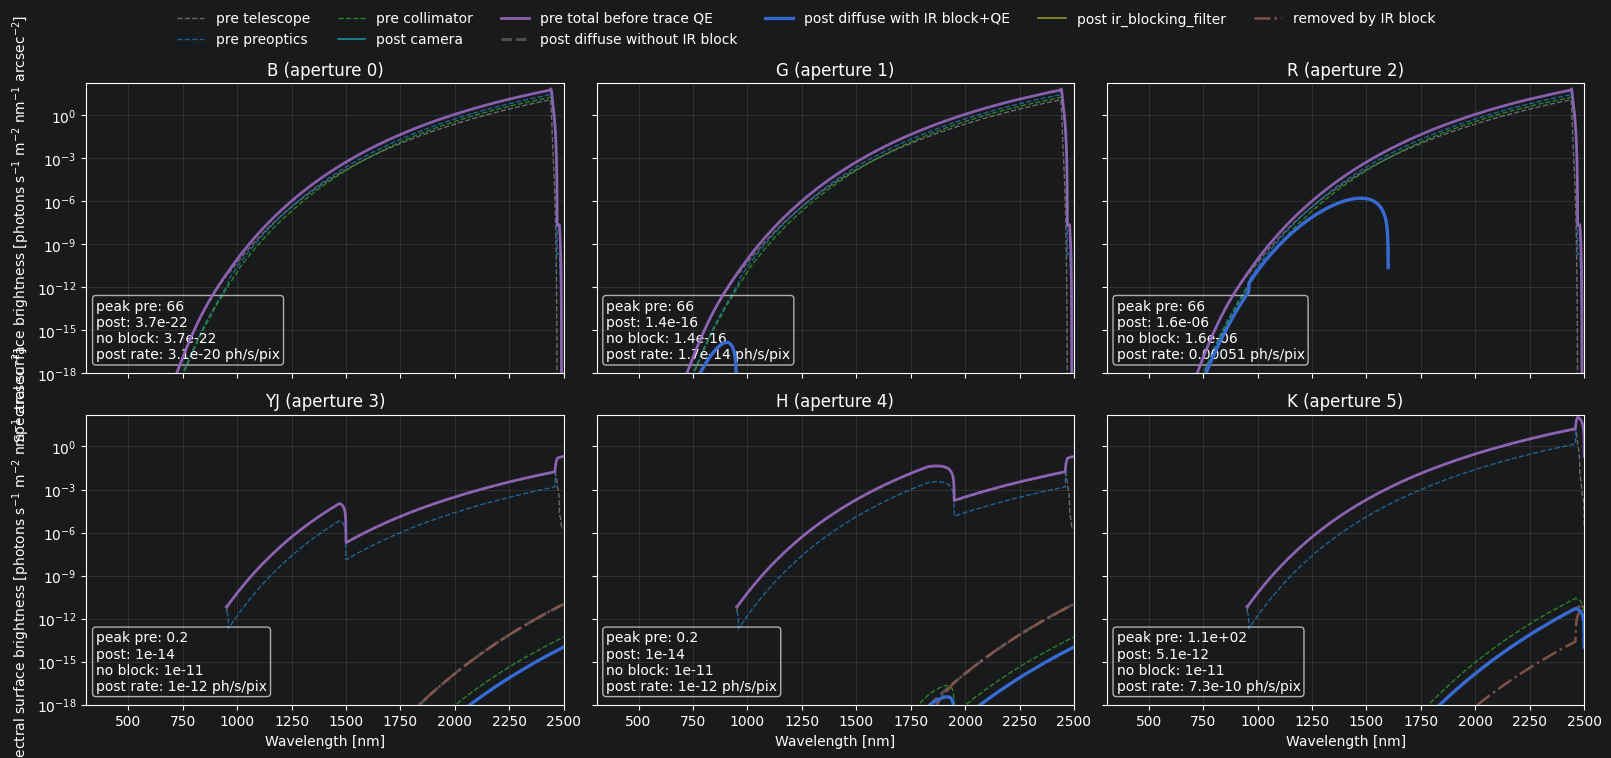

In [10]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)
emissivity_data["details"] #.show_in_notebook(display_length=-1)


## Post-Echelle Diffuse Background

This check collapses only optics tagged `emission_phase = post_disperser` into image-plane background rates. It uses detector QE as throughput only; detector emissivity is not treated as an emissive source. The plot compares the diffuse spectrum with and without the final `ir_blocking_filter_selector`, and each panel title reports the filtered rate plus the rate removed by that filter.

For tapered QE, this diffuse path currently uses `effective_diffuse_throughput`: a uniform average over the configured detector-axis samples. That is a deliberate approximation for non-trace-mapped illumination. It is not yet a wavelength-integrated pixel sensitivity frame; the accounting table below records this so the approximation is visible.

component,surface,group,emission_phase,action,temperature,included_as_diffuse,qe_applied,peak_after_qe,aperture_id,image_plane_id,channel
str27,str27,str18,str14,str12,int64,bool,bool,float64,int64,int64,str2
telescope_reflection,M1,telescope,pre_disperser,reflection,4,False,False,nan,0,0,B
telescope_reflection,M2,telescope,pre_disperser,reflection,4,False,False,nan,0,0,B
telescope_reflection,M3,telescope,pre_disperser,reflection,4,False,False,nan,0,0,B
channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0,False,False,nan,0,0,B
channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0,False,False,nan,0,0,B
channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0,False,False,nan,0,0,B
channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0,False,False,nan,0,0,B
channel_optics_selector,VIS_Derotator_AR_1,preoptics,pre_disperser,transmission,0,False,False,nan,0,0,B
channel_optics_selector,VIS_Derotator_AR_2,preoptics,pre_disperser,transmission,0,False,False,nan,0,0,B


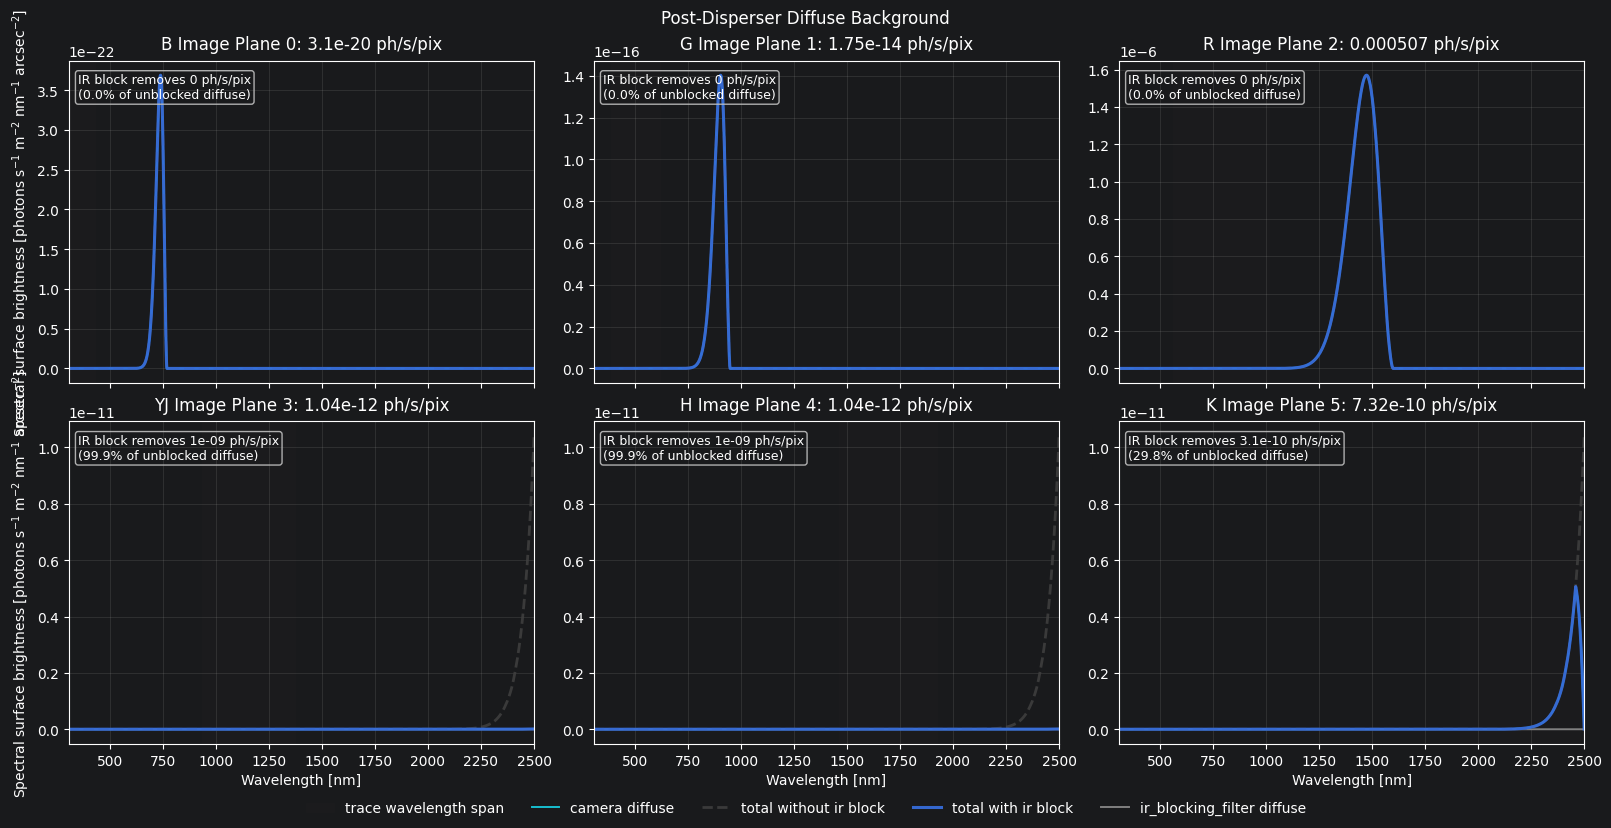

In [11]:
post_diffuse_data = build_post_disperser_diffuse_background_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_post_disperser_diffuse_background_data(post_diffuse_data)
fig, axes = plot_post_disperser_diffuse_background(post_diffuse_data)
post_diffuse_data["details"]  #.show_in_notebook(display_length=-1)


## Detector QE Accounting

This table records how QE was evaluated in each validation path. The key distinction is trace-mapped light versus diffuse illumination: trace-mapped order totals use detector positions, while diffuse post-disperser background uses the current detector-axis average unless a future pixel sensitivity frame is implemented.

The validation builders above call the QE selector with `qe_selector_name=None`, so they follow the single enabled QE selector in the active YAML rather than relying on a fixed effect name. That keeps the standard spectral QE and tapered flattop QE cases switchable by enabling/disabling effects in the YAML.


In [12]:
qe_accounting = detector_qe_accounting_table(transmission_data, emissivity_data, post_diffuse_data)
qe_accounting.show_in_notebook(display_length=-1)

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [13]:
post_diffuse_consistency = post_disperser_diffuse_effect_consistency_table(zs, post_diffuse_data, qe_selector_name=None, component_metadata=component_metadata)
validate_post_disperser_diffuse_effect_consistency(post_diffuse_consistency)
post_diffuse_consistency


aperture_id,channel,image_plane_id,effect_class,effect_included,surface_file,detector_qe_file,pixel_area_arcsec2,helper_rate_ph_s_pix,effect_rate_ph_s_pix,helper_rel_delta,matched_helper_rate_ph_s_pix,matched_rel_delta
int64,str2,int64,str30,bool,str32,object,float64,float64,float64,float64,float64,float64
0,B,0,PostDisperserDiffuseBackground,True,optics/LIST_zspec_vis_optics.dat,None,0.0241989291560025,3.099922707855639e-20,3.099914678480021e-20,2.590192457118838e-06,3.099914678480029e-20,2.7181211035219988e-15
1,G,1,PostDisperserDiffuseBackground,True,optics/LIST_zspec_vis_optics.dat,None,0.0241989291560025,1.746324297524692e-14,1.7463245631073924e-14,-1.520809510628889e-07,1.746324563107394e-14,9.034527966752305e-16
2,R,2,PostDisperserDiffuseBackground,True,optics/LIST_zspec_vis_optics.dat,None,0.0241989291560025,0.0005066536973163497,0.0005066537176407023,-4.011487916357013e-08,0.000506653717640702,-6.419782198782021e-16
3,YJ,3,PostDisperserDiffuseBackground,True,optics/LIST_zspec_nir_optics.dat,detector_specs/APD_TER.dat,0.0241989291560025,1.0433669207828956e-12,1.03375764293679e-12,0.009295484209245248,1.0337576520171927e-12,8.783879569185797e-09
4,H,4,PostDisperserDiffuseBackground,True,optics/LIST_zspec_nir_optics.dat,detector_specs/APD_TER.dat,0.0241989291560025,1.0439144035111673e-12,1.0343050792839509e-12,0.009290609143937445,1.0343050883643533e-12,8.779230247636515e-09
5,K,5,PostDisperserDiffuseBackground,True,optics/LIST_zspec_nir_optics.dat,detector_specs/APD_TER.dat,0.0241989291560025,7.323680160743092e-10,7.32345922450156e-10,3.0168289978661993e-05,7.323459224539891e-10,5.2339358266243935e-12


## Detector Settings Sanity Check

detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
int64,int64,str2,str6,int64,int64,float64,float64
0,0,B,CCD_B,2048,2048,0.015,1.0
1,1,G,CCD_G,2048,2048,0.015,1.0
2,2,R,CCD_R,2048,2048,0.015,1.0
3,3,YJ,APD_YJ,2048,2048,0.015,1.0
4,4,H,APD_H,2048,2048,0.015,1.0
5,5,K,APD_K,2048,2048,0.015,1.0


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
int64,str2,str6,str29,str11,int64,str25,str45
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,"filename=None, current_slit=0.7"
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TaperedQuantumEfficiency,filename=None
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=300.0, ndit=1"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=300.0, ndit=1, value=1e-05"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=1, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,"filename=None, current_slit=0.7"


detector_id,image_plane_id,channel,detector,dit_s,ndit,exposure_time_s,post_diffuse_rate_ph_s_pix,post_diffuse_e_pix,dark_current_e_s_pix,dark_current_e_pix,additive_signal_e_pix,bias_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,read_noise_e_rms,diffuse_shot_noise_e_rms,dark_shot_noise_e_rms,total_noise_e_rms
int64,int64,str2,str6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64
0,0,B,CCD_B,300.0,1.0,300.0,3.099914678480021e-20,9.299744035440063e-18,1e-05,0.003,0.003000000000000009,1040.0,64000.0,4.687500000000014e-08,ok,0.1,3.049548169063749e-09,0.05477225575051661,0.11401754250991385
1,1,G,CCD_G,150.0,1.0,150.0,1.7463245631073924e-14,2.6194868446610887e-12,1e-05,0.0015,0.001500000002619487,1040.0,64000.0,2.3437500040929483e-08,ok,0.1,1.618482883647859e-06,0.03872983346207417,0.10723805295984952
2,2,R,CCD_R,300.0,1.0,300.0,0.0005066537176407023,0.1519961152922107,1e-05,0.003,0.1549961152922107,1040.0,64000.0,2.421814301440792e-06,ok,0.1,0.38986679172790634,0.05477225575051661,0.4061971384589147
3,3,YJ,APD_YJ,300.0,1.0,300.0,1.03375764293679e-12,3.10127292881037e-10,1e-05,0.003,0.003000000310127293,1040.0,64000.0,4.687500484573895e-08,ok,0.5,1.761043136555823e-05,0.05477225575051661,0.5029910539066548
4,4,H,APD_H,300.0,1.0,300.0,1.0343050792839509e-12,3.102915237851853e-10,1e-05,0.003,0.003000000310291524,1040.0,64000.0,4.687500484830506e-08,ok,0.5,1.761509363543621e-05,0.05477225575051661,0.502991053906818
5,5,K,APD_K,300.0,1.0,300.0,7.32345922450156e-10,2.197037767350468e-07,1e-05,0.003,0.003000219703776735,1040.0,64000.0,4.687843287151148e-08,ok,0.5,0.0004687256945539116,0.05477225575051661,0.5029912719956249


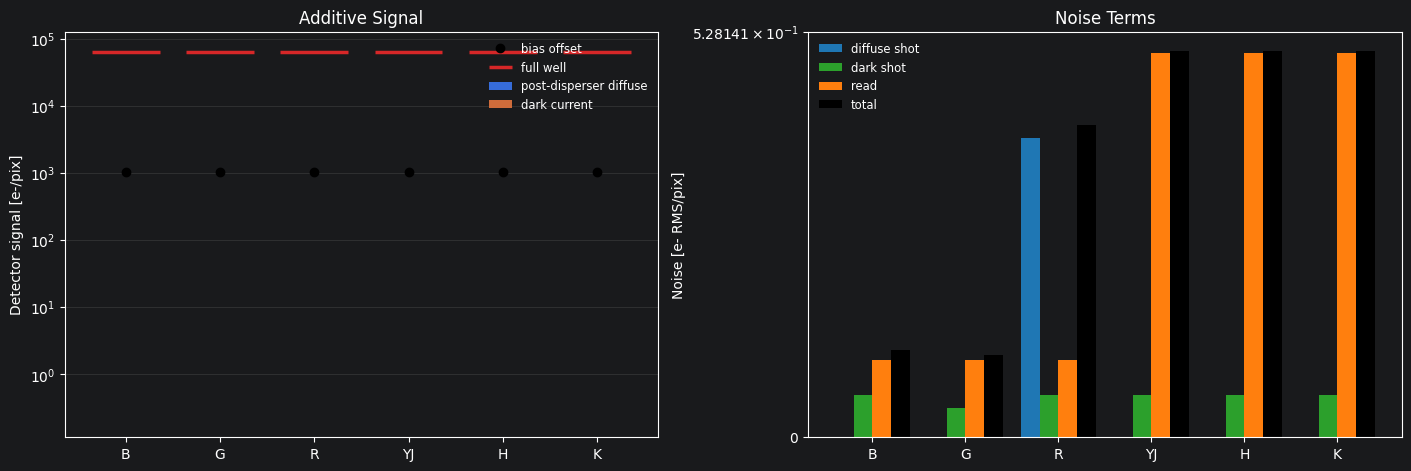

In [14]:
detector_geometry = detector_geometry_table(zs)
detector_settings = detector_selector_matrix(zs)
detector_budget = detector_background_budget_table(
    zs,
    post_diffuse_data=post_diffuse_data,
    post_diffuse_consistency=post_diffuse_consistency,
)
display(detector_geometry)
display(detector_settings)
display(detector_budget)
fig, axes = plot_detector_background_budget(detector_budget)


Now look at the actual detector values for this configuration. Rows with `saturation_status == "saturated"` exceed the configured `!DET.full_well`; those counts are not physically usable detector samples. This is intentionally a validation finding rather than something the notebook fixes automatically. Plausible causes to inspect include excessive DIT/NDIT, bright input source or sky settings, post-disperser thermal camera background, incomplete IR blocking, detector/background assumptions, or an instrument design choice encoded in the YAMLs.


In [15]:
science_truth_checks = science_truth_crosscheck_table(
    zs,
    post_diffuse_data=post_diffuse_data,
    detector_budget=detector_budget,
    extraction_pixels=1.0,
)
science_truth_checks

detector_id,image_plane_id,channel,detector,current_slit_arcsec,wavelength_mid_nm,spectral_resolution_R,resolution_element_nm,pixel_area_arcsec2,post_diffuse_ph_s_pix,post_diffuse_ph_s_arcsec2,extraction_pixels,post_diffuse_ph_s_extraction,post_diffuse_e_extraction,additive_signal_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,note
int64,int64,str2,str6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str2,str120
0,0,B,CCD_B,0.7,366.71742820855206,40000.0,0.009167935705213801,0.0241989291560025,3.099914678480021e-20,1.2810131632254863e-18,1.0,3.099914678480021e-20,9.299744035440063e-18,0.003000000000000009,64000.0,4.687500000000014e-08,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
1,1,G,CCD_G,0.7,502.97660549889133,40000.0,0.012574415137472284,0.0241989291560025,1.7463245631073924e-14,7.216536532874719e-13,1.0,1.7463245631073924e-14,2.6194868446610887e-12,0.001500000002619487,64000.0,2.3437500040929483e-08,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
2,2,R,CCD_R,0.7,788.6890914656911,40000.0,0.01971722728664228,0.0241989291560025,0.0005066537176407023,0.020937030493145926,1.0,0.0005066537176407023,0.1519961152922107,0.1549961152922107,64000.0,2.421814301440792e-06,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
3,3,YJ,APD_YJ,0.7,1153.7043160579951,40000.0,0.02884260790144988,0.0241989291560025,1.03375764293679e-12,4.2719148284310276e-11,1.0,1.03375764293679e-12,3.10127292881037e-10,0.003000000310127293,64000.0,4.687500484573895e-08,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
4,4,H,APD_H,0.7,1693.8545717763786,40000.0,0.042346364294409466,0.0241989291560025,1.0343050792839509e-12,4.274177062200264e-11,1.0,1.0343050792839509e-12,3.102915237851853e-10,0.003000000310291524,64000.0,4.687500484830506e-08,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
5,5,K,APD_K,0.7,2198.329973278686,40000.0,0.05495824933196715,0.0241989291560025,7.32345922450156e-10,3.026356735576867e-08,1.0,7.32345922450156e-10,2.197037767350468e-07,0.003000219703776735,64000.0,4.687843287151148e-08,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."


## Sky Flux sanity check

In [16]:
sky_flux_brightness = "bright"
cmd["!OBS.brightness"] = sky_flux_brightness    # Sky brightness (bright/gray/dark)

# TODO reinit whatever needs reiniting


In [17]:
# Load the effect instances for the different sky background components
# Get emission arrays for each component
wave_th, flux_th = fetch_effect_spectrum_or_transmission(zs, "atmo_transmission", "emission")
wave_cont, flux_cont = fetch_effect_spectrum_or_transmission(zs, "continuum_emission", "emission")
wave_line, flux_line = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "line_TER.emission")
wave_res, flux_res = fetch_effect_spectrum_or_transmission(zs, "airglow_and_interline_continuum", "continuum_TER.emission")

# simple resample all to a common wavelength grid for plotting
common_wave = np.linspace(0.3, 2.5, 10001) * u.um
from scipy.interpolate import CubicSpline
from synphot.units import convert_flux

flux_th_interp = CubicSpline(wave_th, flux_th)(common_wave)
flux_cont_interp = CubicSpline(wave_cont, flux_cont)(common_wave)
flux_line_interp = CubicSpline(wave_line, flux_line)(common_wave)
flux_res_interp = CubicSpline(wave_res, flux_res)(common_wave)

# convert to AB mag for plotting
flux_th_erg = convert_flux(wavelengths=common_wave, fluxes=flux_th_interp, out_flux_unit="abmag")
flux_cont_erg = convert_flux(wavelengths=common_wave, fluxes=flux_cont_interp, out_flux_unit="abmag")
flux_line_erg = convert_flux(wavelengths=common_wave, fluxes=flux_line_interp, out_flux_unit="abmag")
flux_res_erg = convert_flux(wavelengths=common_wave, fluxes=flux_res_interp, out_flux_unit="abmag")


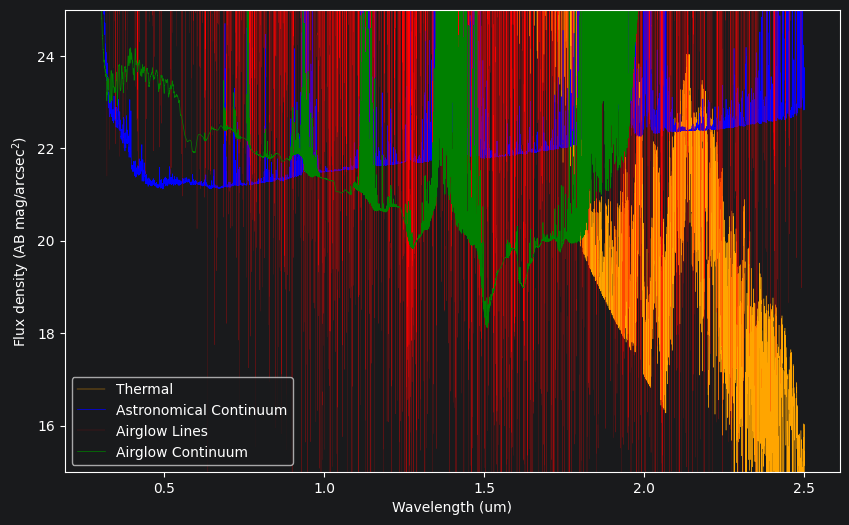

In [18]:
# plot
plt.figure(figsize=(10, 6))
plt.plot(common_wave, flux_th_erg, label='Thermal', color='orange', lw=0.3)
plt.plot(common_wave, flux_cont_erg, label='Astronomical Continuum', color='blue', lw=0.5)
plt.plot(common_wave, flux_line_erg, label='Airglow Lines', color='red', lw=0.1)
plt.plot(common_wave, flux_res_erg, label='Airglow Continuum', color='green', lw=0.5)
plt.xlabel("Wavelength (um)")
plt.ylabel(r"Flux density (AB mag/arcsec$^2$)")
plt.legend()
plt.ylim(15,25)
plt.show()
cmd["!OBS.brightness"] = validation_brightness


# Make and plot sources

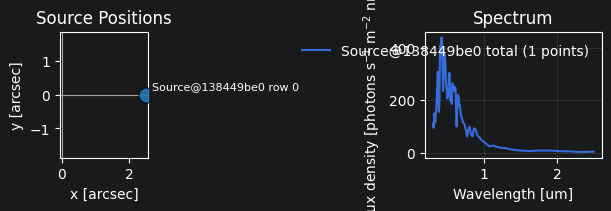

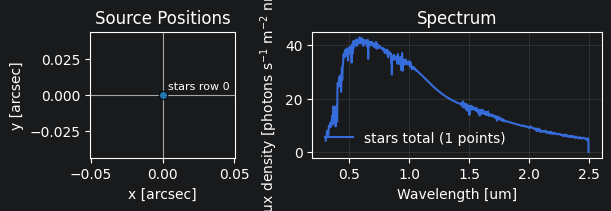

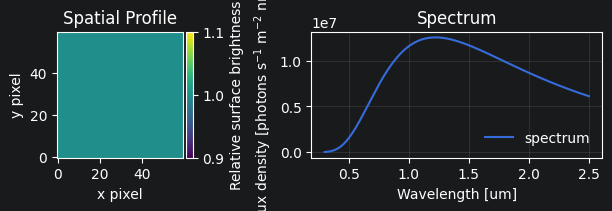

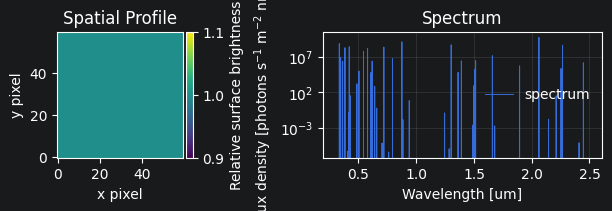

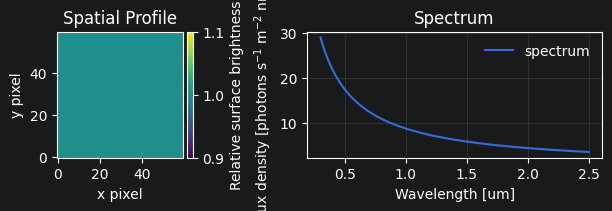

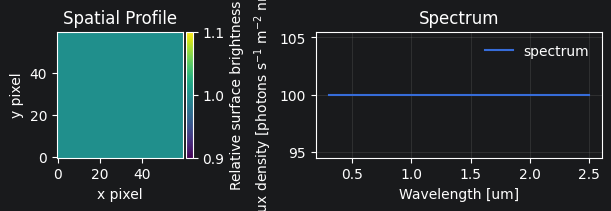

In [19]:
# Fetch a SN1a from spextra library
from spextra import Spextrum
from scopesim.source.source import Source

# ScopeSim Source(...) needs array coordinates and ref=[...] to create a table-backed point-source field.
# In the ZShooter slit frame used here, x is along the slit length and y is across the slit width.
sn1a_source = Source(spectra=Spextrum('sne/sn1a').redshift(0.02).scale_to_magnitude(14*u.ABmag, 'g'), x=[2.5], y=[0.0], ref=[0])
plot_source(sn1a_source)

# scopesim_templates.star wraps scalar x/y internally; pass x=..., y=..., not x=[...], y=[...].
# x=0, y=0 is centered on the slit.
star_source = sim_tp.star('V', 16*u.ABmag, spec_type="G5V", x=0, y=0, library="pyckles")
plot_source(star_source)

# Calibration extended sources
quartz_flat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=4*u.ABmag, filter_curve='V', extend=60)
plot_source(quartz_flat)

lamp_flat_source = lamp_flat(zshooter_dir=zshooter_dir)
plot_source(lamp_flat_source, spectrum_yscale="log", spectrum_linewidth=0.7)

# Uniformly source with const AB mag
uniform_flat_source = ab_magnitude_flat(mag=17, extent=60)
plot_source(uniform_flat_source)

# Uniformly illuminated source with a const photon flux density of 1 photon/s/cm^2/Angstrom
constant_photon_flux_flat = make_constant_photon_flux_flat(amplitude=0.001, extent=60)
plot_source(constant_photon_flux_flat);


## Slit, ADC, and PSF Geometry Sanity Check

These scenes are deliberately simple two-point-source checks. The helper positions are expressed in the ZShooter slit frame used by the ScopeSim source table and slit files: x is along the slit length and y is across the slit width. At `slit_pair_angle = 0 deg`, the default pair is along the slit; changing `slit_pair_angle` rotates the pair partly across the slit, then the source-minus-empty detector plot below shows whether the readout changed accordingly. The current `cmd["!OBS.pupil_angle"]` is printed for context but is not applied to these slit-frame source coordinates.

The configuration table below is context only. It records the active slit setting and any active ADC/dispersion/PSF-like effects or ADC-named optical surfaces; it does not replace detector-level slit-loss or AO/PSF validation.

The scene and slit-loss plots intentionally apply the PSF and chromatic atmospheric shifts before slit clipping. That exposes the physical slit-loss question directly. The current ScopeSim detector pipeline applies convolution after aperture clipping, so these figures are validation diagnostics rather than a complete duplicate of the detector simulation. ScopeSim's `ADCShift` convention is also represented directly: the ADC case is a residual shift model, not AD followed by a separate correction image.

The source preview uses `plot_source(..., individual=True)` for table-backed point-source scenes so each discrete source keeps its table label. The wavelength-dependent slit-loss curves and slit-width sweep use the active ScopeSim PSF FWHM path where available. They compare seeing/no-AO and AO design cases without changing `zs` or the active optical train.


category,scope,name,class,setting,note
str22,str28,str23,str16,str118,str105
slit,"aperture_id 0, 1, 2, 3, 4, 5",slitwheel_selector,SlitWheel,current_slit=0.7,filename_format=slits/slit_{:.2f}_as.dat
adc optics,"aperture_id 0, 1, 2",channel_optics_selector,SurfaceList,"VIS_ADC_12, VIS_ADC_34",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
adc optics,"aperture_id 3, 4, 5",channel_optics_selector,SurfaceList,"NIR_ADC_1, NIR_ADC_2, NIR_ADC_3, NIR_ADC_4",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
atmospheric dispersion,global,adc_residuals,ADCShift,filename=adc_residuals.dat,
psf,global,seeing_psf,AOEnhanceablePSF,"filename=None, fwhm={'seeing': 0.65, 'seeing_unit': 'arcsec', 'pivot_wave': 500, 'pivot_wave_unit': 'nm'}, alpha=4.765",


Using slit-frame source-pair angle=0.00 deg; !OBS.pupil_angle is 0.00 deg.

along_slit_centered


source_index,label,x_arcsec,y_arcsec,in_slit
int64,str8,float64,float64,bool
0,source_0,-2.5,0.0,True
1,source_1,2.5,0.0,True



across_slit_one_off


source_index,label,x_arcsec,y_arcsec,in_slit
int64,str8,float64,float64,bool
0,source_0,0.0,0.0,True
1,source_1,5.5109105961630896e-17,0.9,False



notebook_star_centered


source_index,label,x_arcsec,y_arcsec,in_slit
int64,str8,float64,float64,bool
0,source_0,0.0,0.0,True



notebook_sn1a_plus2p5_along_slit


source_index,label,x_arcsec,y_arcsec,in_slit
int64,str8,float64,float64,bool
0,source_0,2.5,0.0,True



quartz_flat
No table-backed point-source positions for slit geometry: Expected exactly one table source field; found 0.

lamp_flat
No table-backed point-source positions for slit geometry: Expected exactly one table source field; found 0.

uniform_flat
No table-backed point-source positions for slit geometry: Expected exactly one table source field; found 0.

constant_photon_flux_flat
No table-backed point-source positions for slit geometry: Expected exactly one table source field; found 0.


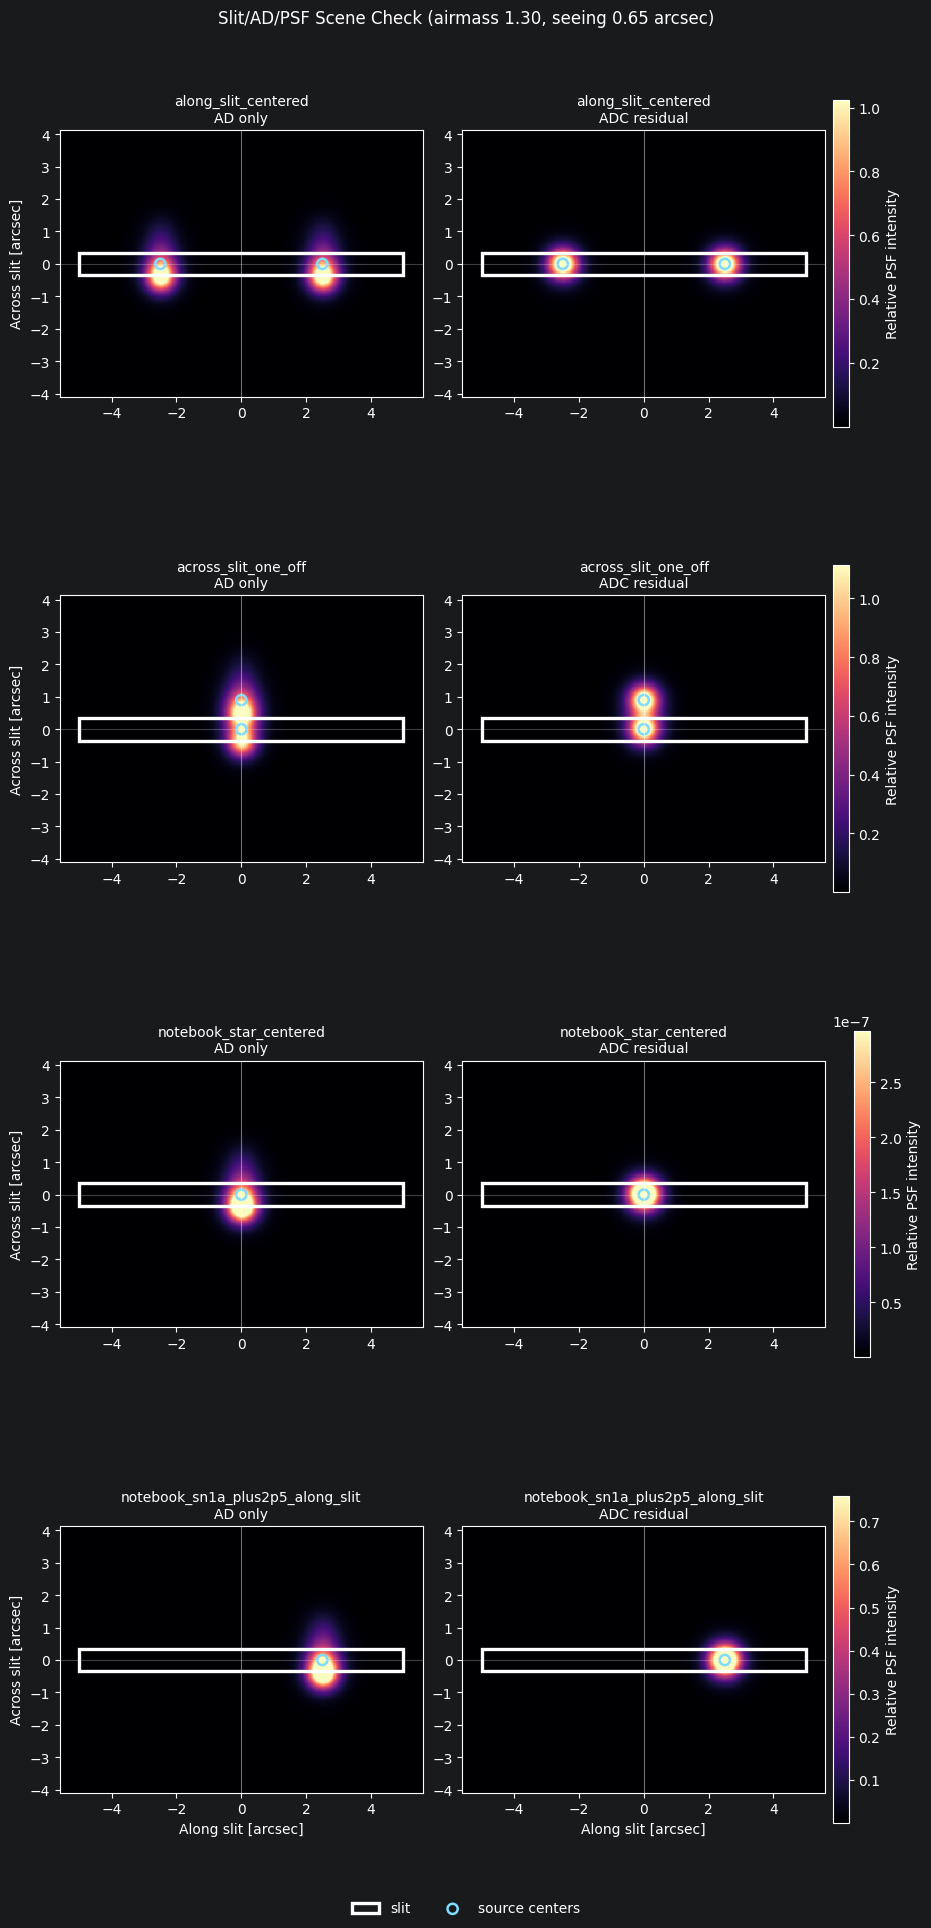

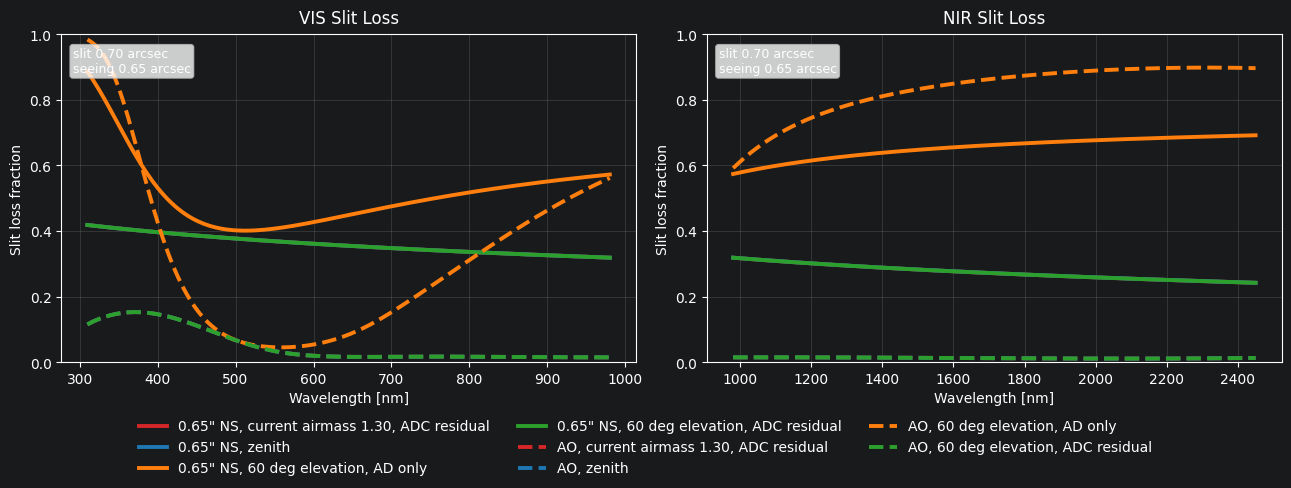

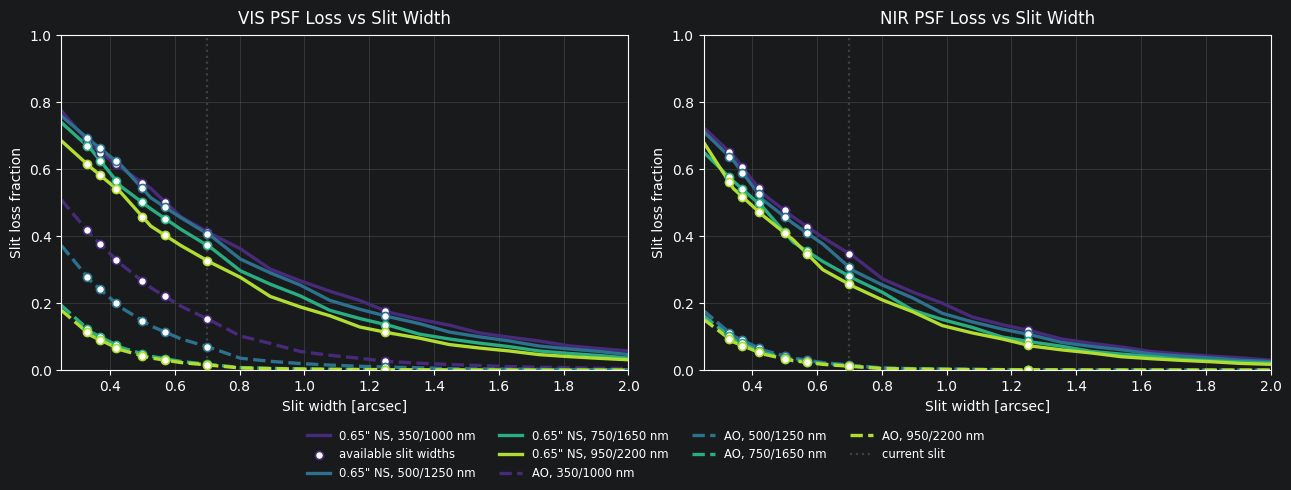

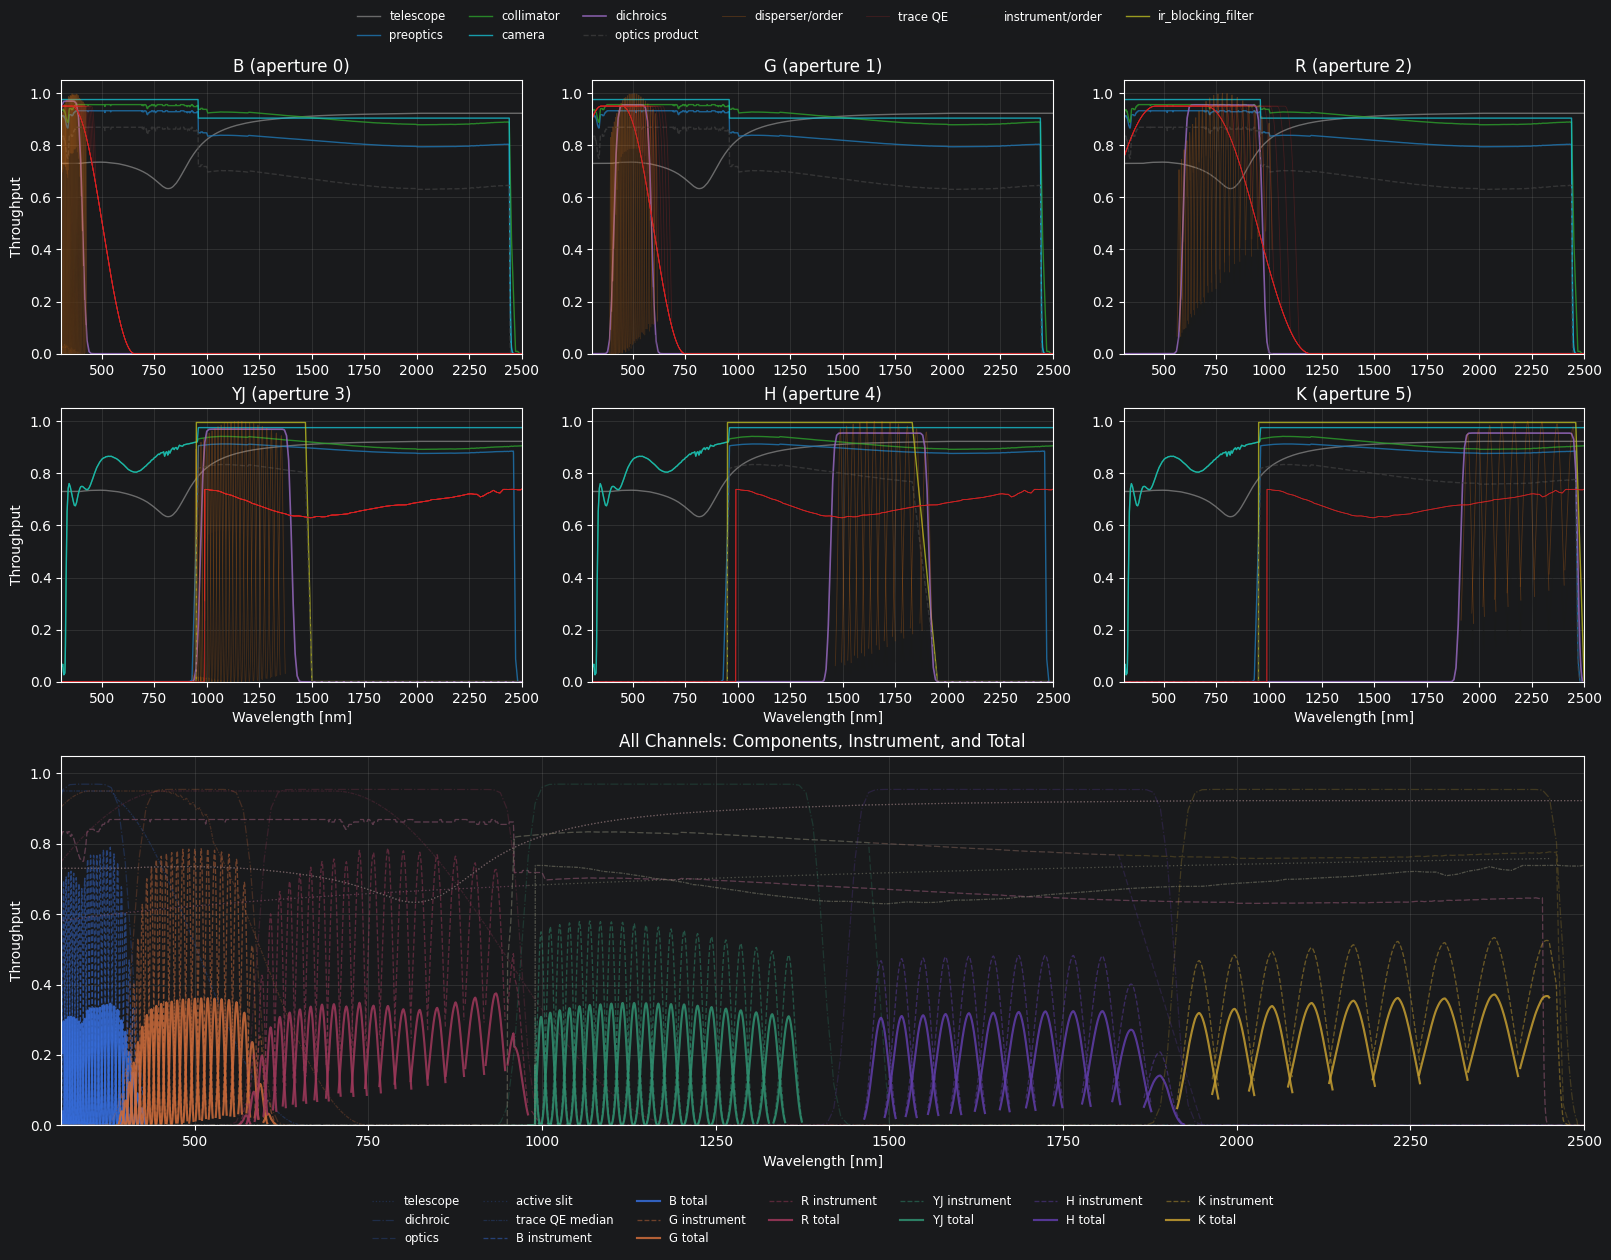

In [20]:
slit_context = slit_adc_psf_status_table(zs)
display(slit_context)

vis_slit_width = u.Quantity(from_currsys("!INST.vis_curr_slit", cmd), u.arcsec)
slit_length = 10 * u.arcsec  # TODO pull from yaml
configured_pupil_angle = angle_from_cmds(cmd, "!OBS.pupil_angle")
slit_pair_angle = 0 * u.deg
print(f"Using slit-frame source-pair angle={slit_pair_angle.to_value(u.deg):.2f} deg; !OBS.pupil_angle is {configured_pupil_angle.to_value(u.deg):.2f} deg.")

slit_validation_sources = dict(field_angle_demo_sources(
    along_separation=5.0 * u.arcsec,
    across_separation=0.9 * u.arcsec,
    angle_on_slit=slit_pair_angle,
    along_mag=15,
    across_mag=17,
))
slit_validation_sources.update({
    "notebook_star_centered": star_source,
    "notebook_sn1a_plus2p5_along_slit": sn1a_source,
    "quartz_flat": quartz_flat,
    "lamp_flat": lamp_flat_source,
    "uniform_flat": uniform_flat_source,
    "constant_photon_flux_flat": constant_photon_flux_flat,
})

point_source_slit_validation_sources = {}
for scenario, source in slit_validation_sources.items():
    print(f"\n{scenario}")
    try:
        positions = source_position_table(source)
    except (TypeError, ValueError) as exc:
        print(f"No table-backed point-source positions for slit geometry: {exc}")
        continue
    point_source_slit_validation_sources[scenario] = source
    status = slit_pair_status_table(positions, slit_width=vis_slit_width, slit_length=slit_length)
    display(status)

slit_scene_data = build_slit_adc_psf_scene_data(
    zs,
    point_source_slit_validation_sources,
    slit_width=vis_slit_width,
    slit_length=slit_length,
)
fig, axes = plot_slit_adc_psf_scenes(slit_scene_data)

slit_loss_data = build_slit_loss_data(zs, slit_length=slit_length)
fig, axes = plot_slit_loss_by_arm(slit_loss_data)

slit_width_loss_data = build_slit_width_loss_data(zs, slit_length=slit_length)
fig, axes = plot_slit_width_loss(slit_width_loss_data)

fig, axes = plot_transmission_sanity(transmission_data, slit_loss_data=slit_loss_data)

# The default expensive observe/readout below now uses this pair so the
# detector images show whether the two traces land on the slit as expected.
source_to_observe = slit_validation_sources["along_slit_centered"]


In [21]:
_BACKGROUND_EFFECT_NAMES = {
    "sky_continuum": ("continuum_emission",),
    "sky_lines": ("airglow_and_interline_continuum",),
    "sky": ("continuum_emission", "airglow_and_interline_continuum"),
    "diffuse_emissivity": ("post_echelle_diffuse_background_selector",),
}


@contextmanager
def disable_background(name_or_names):
    if name_or_names is None:
        yield
        return
    requested = [name_or_names] if isinstance(name_or_names, str) else list(name_or_names)
    effect_names = []
    for name in requested:
        if name not in _BACKGROUND_EFFECT_NAMES:
            raise ValueError(f"Unknown background selector {name!r}; choose from {sorted(_BACKGROUND_EFFECT_NAMES)}")
        effect_names.extend(_BACKGROUND_EFFECT_NAMES[name])
    effects = []
    for effect_name in dict.fromkeys(effect_names):
        effect = get_effect(zs, effect_name, active_only=False)
        effects.append((effect, getattr(effect, "include", True)))
    try:
        for effect, _include in effects:
            effect.include = False
        yield
    finally:
        for effect, include in effects:
            effect.include = include


def show_and_save_hdul(hdul, titles=('B', 'G', 'R', 'YJ', 'H', 'K'), reference_hdul=None, save=True, output_dir=output_dir, readout_clip=0.995, delta_clip=0.995):
    readout_scale_groups = (("B", "G", "R"), ("YJ", "H", "K"))

    fig_overview, axes = plot_readout_overview(hdul, titles=titles, clip=readout_clip, shared_scale=readout_scale_groups, annotate_stats=True)
    fig_cut, axes = plot_readout_cross_dispersion_cut(hdul, titles=titles)

    if save:
        fig_overview.savefig(output_dir / "zspec_echellogram.png", dpi=300)
        for title, channel_hdul in zip(titles, hdul):
            channel_hdul.writeto(output_dir / f"zspec_{title}.fits", overwrite=True)

    fig_delta = None
    if reference_hdul is not None:
        readout_delta = readout_delta_summary_table(hdul, reference_hdul, titles=titles)
        display(readout_delta)
        fig_delta, axes_delta = plot_readout_delta_overview(hdul, reference_hdul, titles=titles, clip=delta_clip, shared_scale=readout_scale_groups)

    return fig_cut, fig_delta

## Fallback to check a pointsource

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

astar.scopesim.utils - WARNING: Obstime is not after sunset!


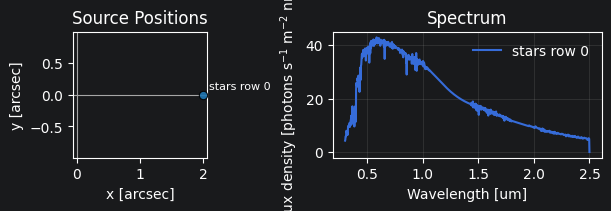

In [22]:
# +2 arcsec along the slit: x=+2, y=0
star_on_slit_plus2 = sim_tp.star('V', 16*u.ABmag, spec_type="G5V", x=2.0, y=0.0, library="pyckles")
# Choose one to simulate:
source_to_observe = star_on_slit_plus2

plot_source(source_to_observe, individual=True)

logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
with disable_scopesim_progress_bars(hide_scopesim_progress):
    zs.observe(source_to_observe)
hdul = zs.readout()

(<Figure size 1320x640 with 6 Axes>, None)

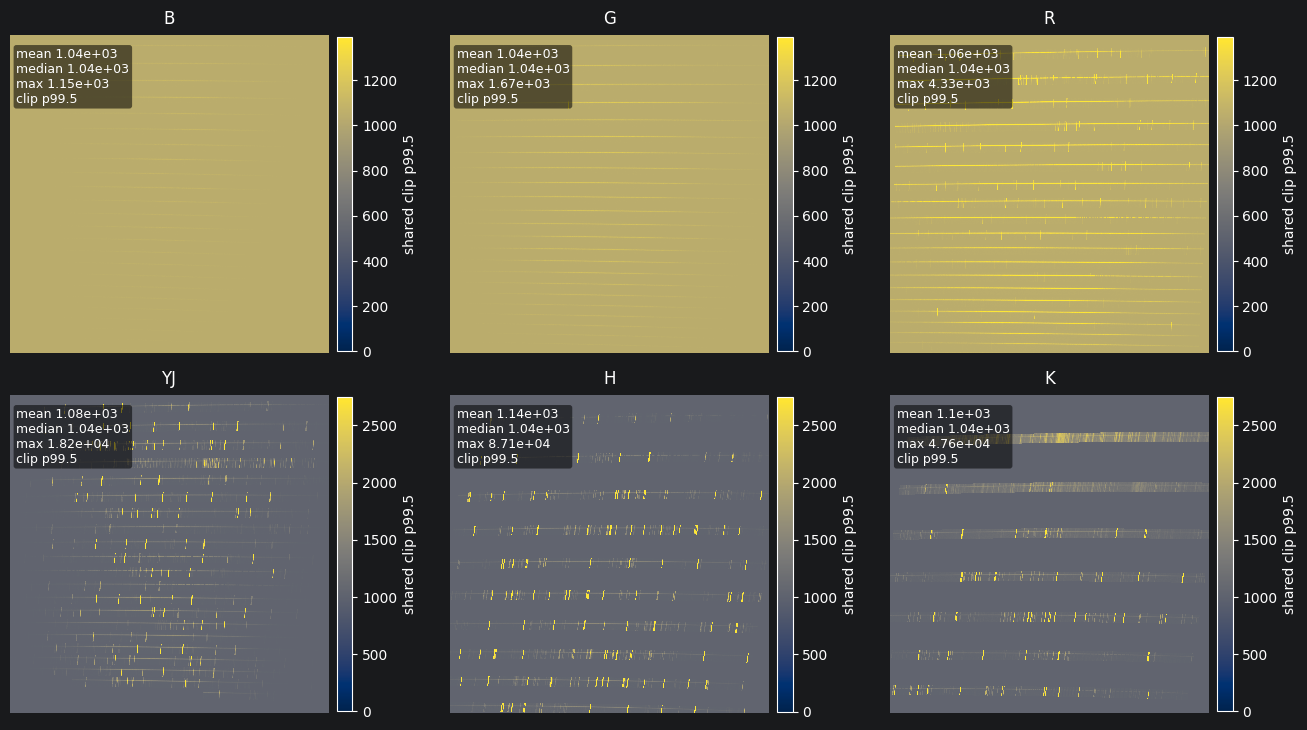

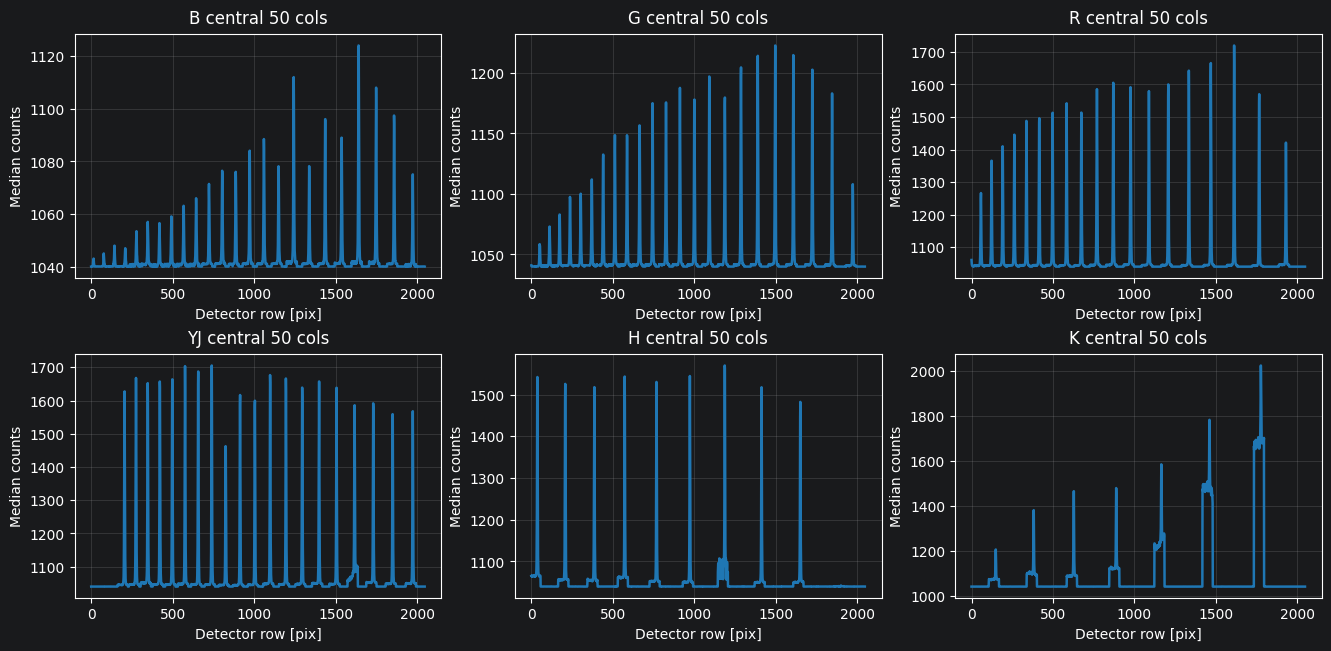

In [23]:
show_and_save_hdul(hdul)

## Simulate it!

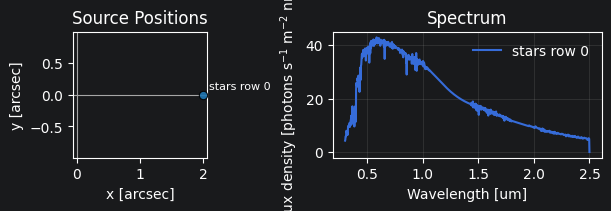

In [24]:
if "source_to_observe" not in globals():
    raise RuntimeError(
        "Run the Slit, ADC, and PSF Geometry Sanity Check cell first; "
        "it explicitly sets source_to_observe."
    )

plot_source(source_to_observe, individual=True);

source_photon_checks = source_photon_crosscheck_table(
    source_to_observe,
    zs,
    transmission_data,
    detector_budget=detector_budget,
)
# source_photon_checks


In [25]:
star_source, source_to_observe

([0]: Table with 1 rows, referencing spectra {0},
 [0]: Table with 1 rows, referencing spectra {0})

In [26]:
logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
with disable_scopesim_progress_bars(hide_scopesim_progress):
    zs.observe(source_to_observe)


py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



#### Read it out

In [27]:
logging.getLogger("astar.scopesim").setLevel(logging.DEBUG)
source_hdul = zs.readout()
hdul = source_hdul


astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: 300 given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: 2 given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 300.0 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selec

## Show it

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
int64,str2,str9,float64,float64,float64,float64,float64,float64,int64
0,B,2048x2048,5131689.0,5131689.0,0.0,105.0,0.0,105.0,1040641
1,G,2048x2048,18445713.0,18445713.0,0.0,628.0,0.0,628.0,1684239
2,R,2048x2048,87992429.0,88252683.0,-260254.0,3290.0,-4.0,3290.0,2686355
3,YJ,2048x2048,173530225.0,173530225.0,0.0,17136.0,0.0,17136.0,1978372
4,H,2048x2048,404339379.0,404397800.0,-58421.0,86102.0,-11.0,86102.0,1152800
5,K,2048x2048,143234861.0,146524541.0,-3289680.0,46512.0,-202.0,46512.0,840040


(<Figure size 1320x640 with 6 Axes>, <Figure size 1320x720 with 12 Axes>)

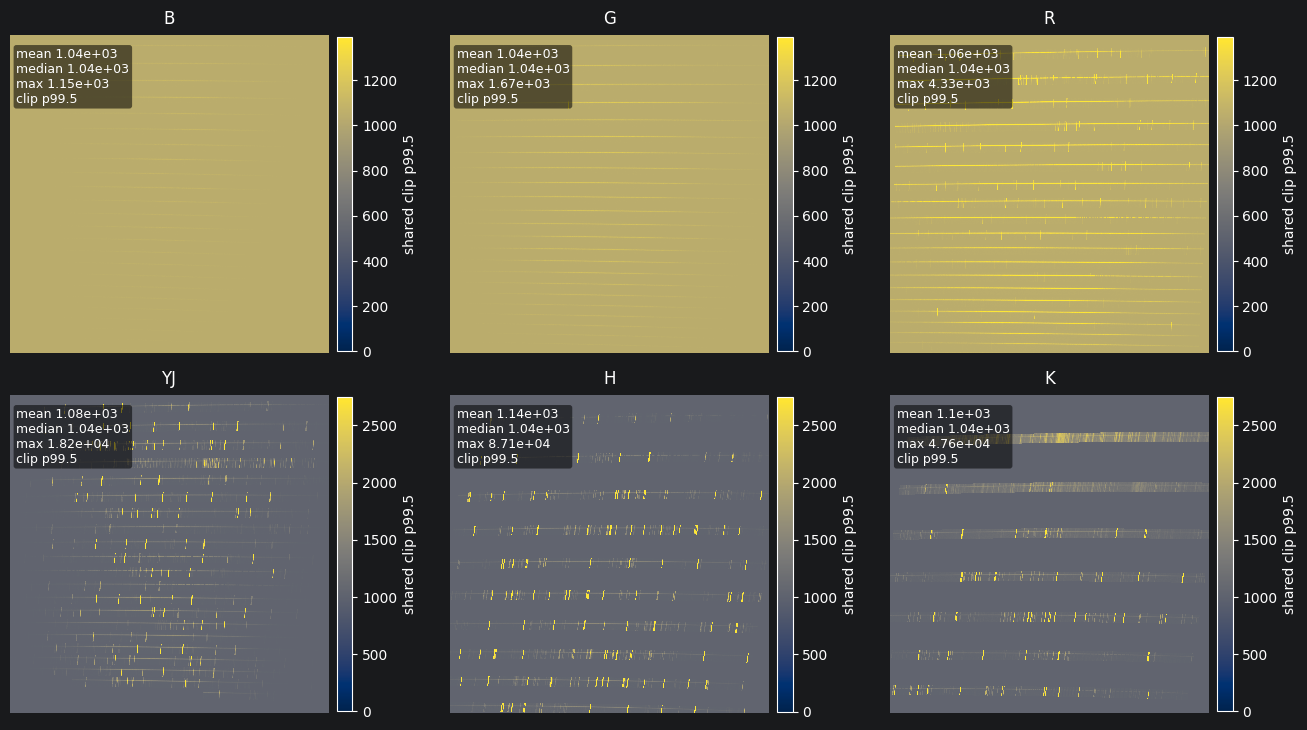

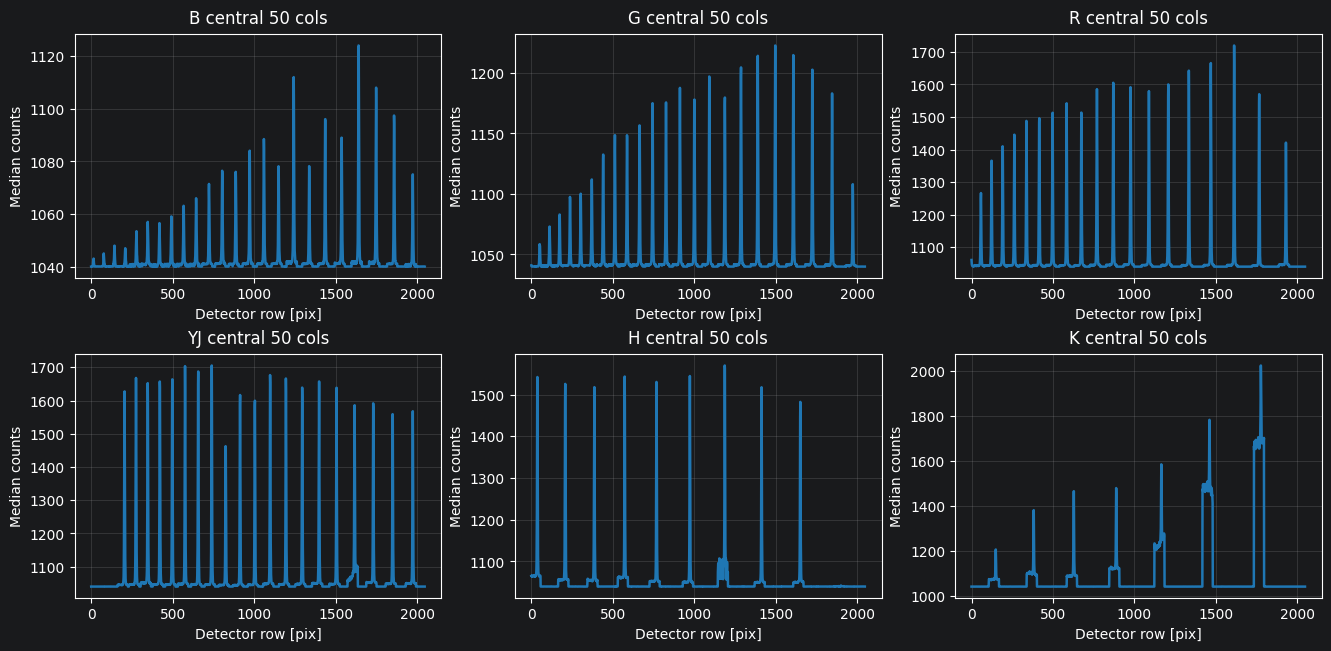

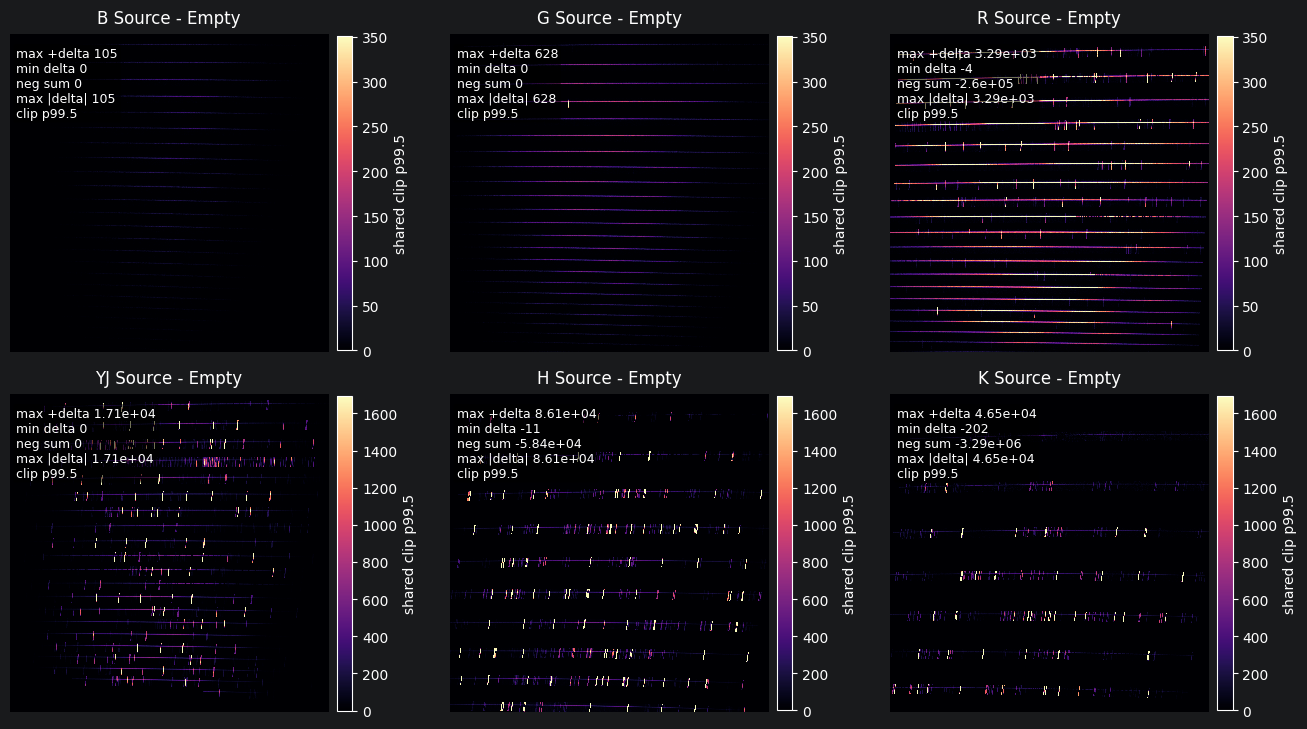

In [28]:
# Expensive but important for this validation: compare the requested source
# readout to an empty-field readout, because absolute scaling can hide compact
# source traces under bright diffuse/background terms. Set False when runtime
# matters more than this source-injection check.
run_empty_readout_reference = True

# Set to None to keep the empty-reference background exactly like the source readout.
# Otherwise choose from: "sky", "sky_continuum", "sky_lines", "diffuse_emissivity".
# "sky" disables sky emission only; atmo_transmission may remain enabled because with
# no sky emission and an empty scene it multiplies zero signal and has no impact.
disable_reference_background = ["sky"]

reference_hdul = None
if run_empty_readout_reference and reference_hdul is None:
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    with disable_background(disable_reference_background), disable_scopesim_progress_bars(hide_scopesim_progress):
        zs.observe()
        reference_hdul = zs.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.DEBUG)


show_and_save_hdul(hdul, reference_hdul=reference_hdul)